# scOPE — GBM (TCGA Glioblastoma Multiforme)

1. **Phase 1** — TCGA GBM bulk RNA-seq + MC3 mutations.
2. **Phase 2** — Neftel et al. 2019 (Cell) GBM scRNA-seq
   (GSE131928, ~24 000 cells, 28 GBMs).

**Data notes:**
- Bulk: Xena HiSeqV2_PANCAN, log2(norm_count+1).
- SC: GSE131928 — `GSE131928_single_cells_tumor_sample_TPM.txt.gz`
  is log2(TPM+1) — no further normalisation applied.


## 1. Imports & paths

In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests

from scope import BulkPipeline, SingleCellPipeline
from scope.visualization import (
    compute_umap,
    plot_mutation_probabilities,
    plot_scree,
    plot_mutation_heatmap,
)

mpl.rcParams['figure.dpi']    = 100
mpl.rcParams['savefig.dpi']   = 300
mpl.rcParams['figure.figsize'] = (10, 6)


In [2]:
BASE_DIR   = "/home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data"
BULK_DIR   = os.path.join(BASE_DIR, "TCGA_GBM")
SC_DIR     = os.path.join(BASE_DIR, "GBM_scRNA")
MODELS_DIR = os.path.join(BASE_DIR, "..", "models", "GBM")
CANCER_TAG = "GBM"

for d in [BULK_DIR, SC_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

gbm_expr_path  = os.path.join(BULK_DIR, "TCGA_GBM_HiSeqV2_PANCAN.tsv.gz")
mc3_path       = os.path.join(BULK_DIR, "mc3.v0.2.8.PUBLIC.xena.gz")
sc_tpm_path    = os.path.join(SC_DIR,   "GSE131928_tpm.txt.gz")
sc_meta_path   = os.path.join(SC_DIR,   "GSE131928_meta.txt.gz")


## 2. Download raw data

In [3]:
XENA_BASE = "https://tcga.xenahubs.net/download"
if os.path.exists(gbm_expr_path):
    print(f"  already present -- {os.path.basename(gbm_expr_path)}")
else:
    print("  downloading TCGA GBM expression ...")
    r = requests.get(f"{XENA_BASE}/TCGA.GBM.sampleMap/HiSeqV2_PANCAN.gz",
                     stream=True, timeout=300)
    r.raise_for_status()
    with open(gbm_expr_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {gbm_expr_path}")


  downloading TCGA GBM expression ...
  done -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/TCGA_GBM/TCGA_GBM_HiSeqV2_PANCAN.tsv.gz


In [4]:
# -- MC3 PanCanAtlas MAF -- all TCGA cancer types, one file (~200 MB) -------
# Check sibling directories before downloading to avoid re-fetching.
_mc3_alts = [
    os.path.join(BASE_DIR, sib, "mc3.v0.2.8.PUBLIC.xena.gz")
    for sib in ["TCGA_CRC", "TCGA_SKCM", "TCGA_BRCA", "TCGA_LUAD",
                "TCGA_GBM", "TCGA_PAAD", "TCGA_LIHC", "TCGA_LAML"]
]
for _alt in _mc3_alts:
    if not os.path.exists(mc3_path) and os.path.exists(_alt):
        import shutil; shutil.copy(_alt, mc3_path)
        print(f"  copied MC3 from {os.path.dirname(_alt)}")
        break

if not os.path.exists(mc3_path):
    print("Downloading MC3 MAF (~200 MB) ...")
    r = requests.get(
        "https://pancanatlas.xenahubs.net/download/mc3.v0.2.8.PUBLIC.xena.gz",
        stream=True, timeout=600,
    )
    r.raise_for_status()
    with open(mc3_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {mc3_path}")
else:
    print(f"  already present -- {os.path.basename(mc3_path)}")


  copied MC3 from /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/TCGA_CRC
  already present -- mc3.v0.2.8.PUBLIC.xena.gz


In [8]:
import tarfile

sc_tar_path = os.path.join(SC_DIR, "GSE131928_RAW.tar")

GEO_FTP = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE131nnn/GSE131928/suppl"

if not os.path.exists(sc_tar_path):
    print("Downloading GSE131928_RAW.tar (~638 MB) ...")
    _download_ncbi(f"{GEO_FTP}/GSE131928_RAW.tar", sc_tar_path)
    print(f"  done -> {sc_tar_path}")
else:
    print("  already present -- GSE131928_RAW.tar")

# -- Inspect contents before extracting ------------------------------------
with tarfile.open(sc_tar_path) as tar:
    members = tar.getnames()
    print(f"\n{len(members)} files in archive:")
    for m in members[:30]:
        print(f"  {m}")
        


     0K .......... .......... .......... .......... ..........  0%  370K 29m25s
    50K .......... .......... .......... .......... ..........  0%  750K 21m58s
   100K .......... .......... .......... .......... ..........  0% 1.22M 17m33s
   150K .......... .......... .......... .......... ..........  0% 1.84M 14m36s
   200K .......... .......... .......... .......... ..........  0% 51.5M 11m43s
   250K .......... .......... .......... .......... ..........  0% 74.5M 9m47s
   300K .......... .......... .......... .......... ..........  0%  876K 10m10s
   350K .......... .......... .......... .......... ..........  0% 6.26M 9m6s
   400K .......... .......... .......... .......... ..........  0% 69.7M 8m7s
   450K .......... .......... .......... .......... ..........  0% 60.1M 7m19s
   500K .......... .......... .......... .......... ..........  0% 63.1M 6m40s
   550K .......... .......... .......... .......... ..........  0% 95.1M 6m7s
   600K .......... .......... .......... .......

  done -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/GBM_scRNA/GSE131928_RAW.tar

2 files in archive:
  GSM3828672_Smartseq2_GBM_IDHwt_processed_TPM.tsv.gz
  GSM3828673_10X_GBM_IDHwt_processed_TPM.tsv.gz


In [9]:
# Extract all into SC_DIR
with tarfile.open(sc_tar_path) as tar:
    tar.extractall(SC_DIR)
print("Extracted.")

# Then list what landed
import glob
for f in sorted(glob.glob(os.path.join(SC_DIR, "*.gz"))):
    print(f)
    

Extracted.
/home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/GBM_scRNA/GSM3828672_Smartseq2_GBM_IDHwt_processed_TPM.tsv.gz
/home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/GBM_scRNA/GSM3828673_10X_GBM_IDHwt_processed_TPM.tsv.gz


## 3. Load & prepare bulk RNA-seq

In [10]:
def load_xena_expression(path, cohort, type_map=None):
    """Load Xena HiSeqV2_PANCAN -> samples x genes AnnData."""
    if type_map is None:
        type_map = {"01": "tumor", "11": "normal"}
    df = pd.read_csv(path, sep="\t", index_col=0).T
    keep = df.index.str[13:15].isin(type_map)
    df   = df[keep]
    sample_type = df.index.str[13:15].map(type_map)
    adata = ad.AnnData(
        X   = df.values.astype(np.float32),
        obs = pd.DataFrame({"cohort": cohort, "sample_type": sample_type.values},
                           index=df.index),
        var = pd.DataFrame(index=df.columns),
    )
    for st, label in type_map.items():
        n = (sample_type == label).sum()
        print(f"  {cohort} {label} : {n}")
    return adata


In [11]:
adata_bulk = load_xena_expression(gbm_expr_path, "GBM")
adata_bulk.var_names_make_unique()
print(f"Bulk : {adata_bulk.n_obs} x {adata_bulk.n_vars}")


  GBM tumor : 154
  GBM normal : 5
Bulk : 159 x 20530


## 4. Build mutation label matrix

In [12]:
GBM_GENES = [
    "IDH1",     # ~10% (mostly secondary GBM / lower-grade)
    "IDH2",
    "TP53",     # ~30%
    "PTEN",     # ~40%
    "EGFR",     # ~40% -- amplification + missense
    "PIK3CA",
    "PIK3R1",
    "RB1",
    "CDKN2A",
    "NF1",
    "ATRX",     # IDH-mutant GBM
    "CIC",      # IDH-mutant oligodendroglioma
    "TERT",     # promoter mutation -- technically non-coding but often captured
    "PDGFRA",
    "MDM2",
    "MDM4",
    "CDK4",
    "CDK6",
    "NOTCH1",
    "STAG2",
]
GBM_GENES = list(dict.fromkeys(GBM_GENES))
print(f"Targeting {len(GBM_GENES)} GBM driver genes")


Targeting 20 GBM driver genes


In [13]:
KEEP_CLASSES = {
    "Missense_Mutation", "Nonsense_Mutation", "Frame_Shift_Del",
    "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
    "Splice_Site", "Translation_Start_Site", "Nonstop_Mutation",
}


In [14]:
# -- Filter MC3 to this cancer by matching against bulk 15-char barcodes --
mc3 = pd.read_csv(mc3_path, sep="\t", low_memory=False)
mc3 = mc3.rename(columns={
    "sample": "Tumor_Sample_Barcode",
    "effect": "Variant_Classification",
    "gene":   "Hugo_Symbol",
})
bulk_15_set   = set(adata_bulk.obs_names.str[:15])
mc3["sample_id"] = mc3["Tumor_Sample_Barcode"].str[:15]
maf_cancer    = mc3[mc3["sample_id"].isin(bulk_15_set)].copy()
print(f"Cancer rows (pre-filter) : {len(maf_cancer):,}   "
      f"samples: {maf_cancer['sample_id'].nunique()}")

maf_cancer = maf_cancer[maf_cancer["Variant_Classification"].isin(KEEP_CLASSES)]
maf_all    = maf_cancer[["sample_id", "Hugo_Symbol"]].dropna()
print(f"After coding filter      : {len(maf_all):,} variants   "
      f"{maf_all['sample_id'].nunique()} samples")


Cancer rows (pre-filter) : 31,000   samples: 150
After coding filter      : 20,527 variants   150 samples


In [15]:
mut_matrix = (
    maf_all[["sample_id", "Hugo_Symbol"]].drop_duplicates()
    .assign(mutated=1)
    .pivot_table(index="sample_id", columns="Hugo_Symbol",
                 values="mutated", fill_value=0)
)
mut_matrix.columns.name = None; mut_matrix.index.name = None
genes_present = [g for g in GBM_GENES if g in mut_matrix.columns]
mutation_labels_raw = mut_matrix[genes_present]
is_normal = adata_bulk.obs["sample_type"] == "normal"
has_mc3   = adata_bulk.obs_names.str[:15].isin(mutation_labels_raw.index)
keep_mask = has_mc3 | is_normal.values
adata_bulk = adata_bulk[keep_mask].copy()
adata_bulk.obs["barcode_15"] = adata_bulk.obs_names.str[:15]
mut_re = mutation_labels_raw.copy()
mut_re.index = mut_re.index.str[:15]
mut_re = mut_re[~mut_re.index.duplicated(keep="first")]
mutation_labels = mut_re.reindex(adata_bulk.obs["barcode_15"]).fillna(0).astype(int)
mutation_labels.index = adata_bulk.obs_names
print(f"Mutation matrix : {mutation_labels.shape}")
tmask = adata_bulk.obs["sample_type"] != "normal"
print(mutation_labels[tmask].sum().sort_values(ascending=False).head(15))


Mutation matrix : (155, 17)
TP53      51
PTEN      50
EGFR      44
NF1       16
PIK3CA    14
RB1       13
PIK3R1    12
ATRX      10
IDH1       7
STAG2      7
PDGFRA     7
CIC        3
CDKN2A     3
MDM4       2
TERT       2
dtype: int64


## 5. Load single-cell data — Neftel et al. 2019 (GSE131928)

In [ ]:
import tarfile, glob

sc_tar_path = os.path.join(SC_DIR, "GSE131928_RAW.tar")
sc_xlsx_path = os.path.join(SC_DIR, "GSE131928_single_cells_tumor_name_and_adult_or_peidatric.xlsx")

# -- Download tar if not present -------------------------------------------
GEO_FTP = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE131nnn/GSE131928/suppl"
for dest, fname in [
    (sc_tar_path,  "GSE131928_RAW.tar"),
    (sc_xlsx_path, "GSE131928_single_cells_tumor_name_and_adult_or_peidatric.xlsx"),
]:
    if not os.path.exists(dest):
        print(f"Downloading {fname} ...")
        _download_ncbi(f"{GEO_FTP}/{fname}", dest)
        print(f"  done -> {dest}")
    else:
        print(f"  already present -- {fname}")

# -- Extract if not already done -------------------------------------------
gsm_files = sorted(glob.glob(os.path.join(SC_DIR, "GSM*.txt.gz")))
if not gsm_files:
    print("Extracting RAW.tar ...")
    with tarfile.open(sc_tar_path) as tar:
        tar.extractall(SC_DIR)
    gsm_files = sorted(glob.glob(os.path.join(SC_DIR, "GSM*.txt.gz")))
    print(f"Extracted {len(gsm_files)} files")
else:
    print(f"Already extracted: {len(gsm_files)} GSM files")

print("\nFirst few files:")
for f in gsm_files[:5]:
    print(f"  {os.path.basename(f)}")
    

In [21]:
gsm_files = sorted(glob.glob(os.path.join(SC_DIR, "GSM*.tsv.gz")))
print(f"{len(gsm_files)} GSM files found")

adatas = []
for path in gsm_files:
    fname     = os.path.basename(path)
    sample_id = fname.split("_")[0]
    platform  = "SmartSeq2" if "Smartseq2" in fname else "10X"
    
    df = pd.read_csv(path, sep="\t", index_col=0)   # genes x cells
    print(f"  {sample_id} ({platform}) raw shape: {df.shape}")
    
    a = ad.AnnData(
        X   = df.values.T.astype(np.float32),
        obs = pd.DataFrame({"sample": sample_id, "platform": platform},
                           index=df.columns),
        var = pd.DataFrame(index=df.index),
    )
    adatas.append(a)

adata_sc = ad.concat(adatas, join="inner")
adata_sc.var_names_make_unique()
adata_sc.obs_names_make_unique()
print(f"\nCombined : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Platform breakdown:")
print(adata_sc.obs["platform"].value_counts())

# -- Attach tumour-level metadata from xlsx --------------------------------
try:
    meta = pd.read_excel(sc_xlsx_path, index_col=0)
    print(f"\nMetadata columns: {meta.columns.tolist()}")
    # The xlsx is sample-level; broadcast to cells via the sample column
    sample_to_meta = meta.to_dict(orient="index")
    for col in meta.columns:
        adata_sc.obs[col] = adata_sc.obs["sample"].map(
            {k: v[col] for k, v in sample_to_meta.items()}
        )
    print("Metadata attached.")
except Exception as e:
    print(f"xlsx metadata not attached ({e}) -- proceeding with sample ID only.")

# -- Identify cell state column --------------------------------------------
ct_col = next((c for c in adata_sc.obs.columns
               if "type" in c.lower() or "state" in c.lower()
               or "class" in c.lower() or "tumor" in c.lower()), None)
if ct_col:
    print(f"\nCell annotation ({ct_col}):")
    print(adata_sc.obs[ct_col].value_counts().head(15))
    

2 GSM files found
  GSM3828672 (SmartSeq2) raw shape: (23686, 7930)
  GSM3828673 (10X) raw shape: (30314, 16201)

Combined : 24131 cells x 19135 genes
Platform breakdown:
platform
10X          16201
SmartSeq2     7930
Name: count, dtype: int64
xlsx metadata not attached (Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.) -- proceeding with sample ID only.


In [22]:
# QC (already log2(TPM+1))
sc.pp.filter_genes(adata_sc, min_cells=5)
sc.pp.filter_cells(adata_sc, min_genes=100)
print(f"After QC : {adata_sc.n_obs} x {adata_sc.n_vars}")
print(f"Value range: {adata_sc.X.min():.2f} -- {adata_sc.X.max():.2f}")


After QC : 24131 x 18543
Value range: 0.00 -- 633930.19


## 6-10. Pipeline, visualisation & save

In [23]:
overlap = set(adata_bulk.var_names)&set(adata_sc.var_names)
print(f'Gene overlap : {len(overlap):,}')

Gene overlap : 16,863


In [24]:
n_components = 80
print(f'n_components = {n_components}')

n_components = 80


In [25]:
bulk_pipe = BulkPipeline(
    norm_method         = "none",
    log1p               = False,
    center              = True,
    scale               = True,
    decomposition       = "svd",
    n_components        = n_components,
    classifier          = "logistic",
    min_positive_frac   = 0.0001,
    classifier_kwargs   = {
        "C"        : 1.0,
        "solver"   : "saga",
        "max_iter" : 100000,
    },
)

bulk_pipe.fit(adata_bulk, mutation_labels, cv=10)
bulk_pipe.save(os.path.join(MODELS_DIR, f"{CANCER_TAG}_bulk_pipeline.pkl"))
print("Phase 1 complete -- model saved.")


15:15:50 | INFO     | scope.pipeline.bulk_pipeline — === BulkPipeline.fit ===
15:15:50 | INFO     | scope.pipeline.bulk_pipeline — Preprocessing bulk data (norm=none, log1p=False).
15:15:50 | INFO     | scope.preprocessing.bulk — BulkNormalizer fitted (method=none).
15:15:50 | INFO     | scope.preprocessing.bulk — BulkScaler fitted (center=True, scale=True).
15:15:50 | INFO     | scope.preprocessing.bulk — BulkPreprocessor fitted: 20530 genes → 20530 after filtering.
15:15:50 | INFO     | scope.pipeline.bulk_pipeline — Decomposition: svd (k=80).
15:15:50 | INFO     | scope.decomposition.svd — SVD fitted: 80 components (cumulative EVR=0.863).
15:15:50 | INFO     | scope.pipeline.bulk_pipeline — Training classifiers (logistic).
/home/groups/precepts/ashforda/micromamba/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
15:15:50 | INFO     | scope.c

Phase 1 complete -- model saved.


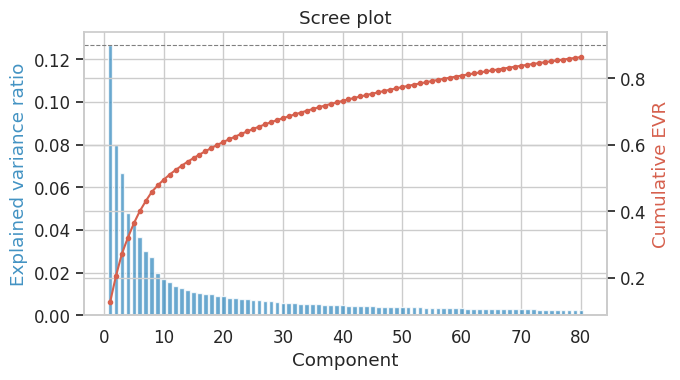

In [26]:
scree = bulk_pipe.decomposer_.scree_data()
fig, ax = plot_scree(scree, max_components=n_components); plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_scree.pdf"), bbox_inches="tight"); plt.show()


In [27]:
adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)

sc_pipe = SingleCellPipeline(
    bulk_pipeline    = bulk_pipe,
    alignment_method = "moment_matching",
)
sc_pipe.fit(adata_bulk_pp, adata_sc)
adata_sc = sc_pipe.transform(adata_sc)

mut_prob_cols = [c for c in adata_sc.obs.columns if c.startswith("mutation_prob_")]
print(f"Inferred {len(mut_prob_cols)} mutation probability columns")


15:16:40 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.fit ===
15:16:40 | INFO     | scope.preprocessing.single_cell — SingleCellPreprocessor fitted.
15:16:43 | INFO     | scope.preprocessing.single_cell — QC filter: removed 1225 / 24131 cells (22906 retained).
15:16:50 | INFO     | scope.utils.gene_utils — Gene universe: 16863 shared, 3667 bulk-only, 1680 sc-only
15:16:57 | INFO     | scope.preprocessing.alignment — BulkSCAligner fitted (method=moment_matching, n_genes=16863).
15:16:57 | INFO     | scope.pipeline.sc_pipeline — SingleCellPipeline.fit complete.
15:16:57 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.transform ===
15:17:00 | INFO     | scope.preprocessing.single_cell — QC filter: removed 1225 / 24131 cells (22906 retained).
15:17:15 | WARNING  | scope.pipeline.sc_pipeline — 3667 / 20530 bulk genes absent from sc data (will be zero-padded).
15:18:07 | INFO     | scope.pipeline.sc_pipeline — Projected 22906 cells into 80-D latent space.

Inferred 17 mutation probability columns


/home/groups/precepts/ashforda/micromamba/envs/scope-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
15:18:50 | INFO     | scope.visualization.embeddings — UMAP computed: 22906 cells → 2D.


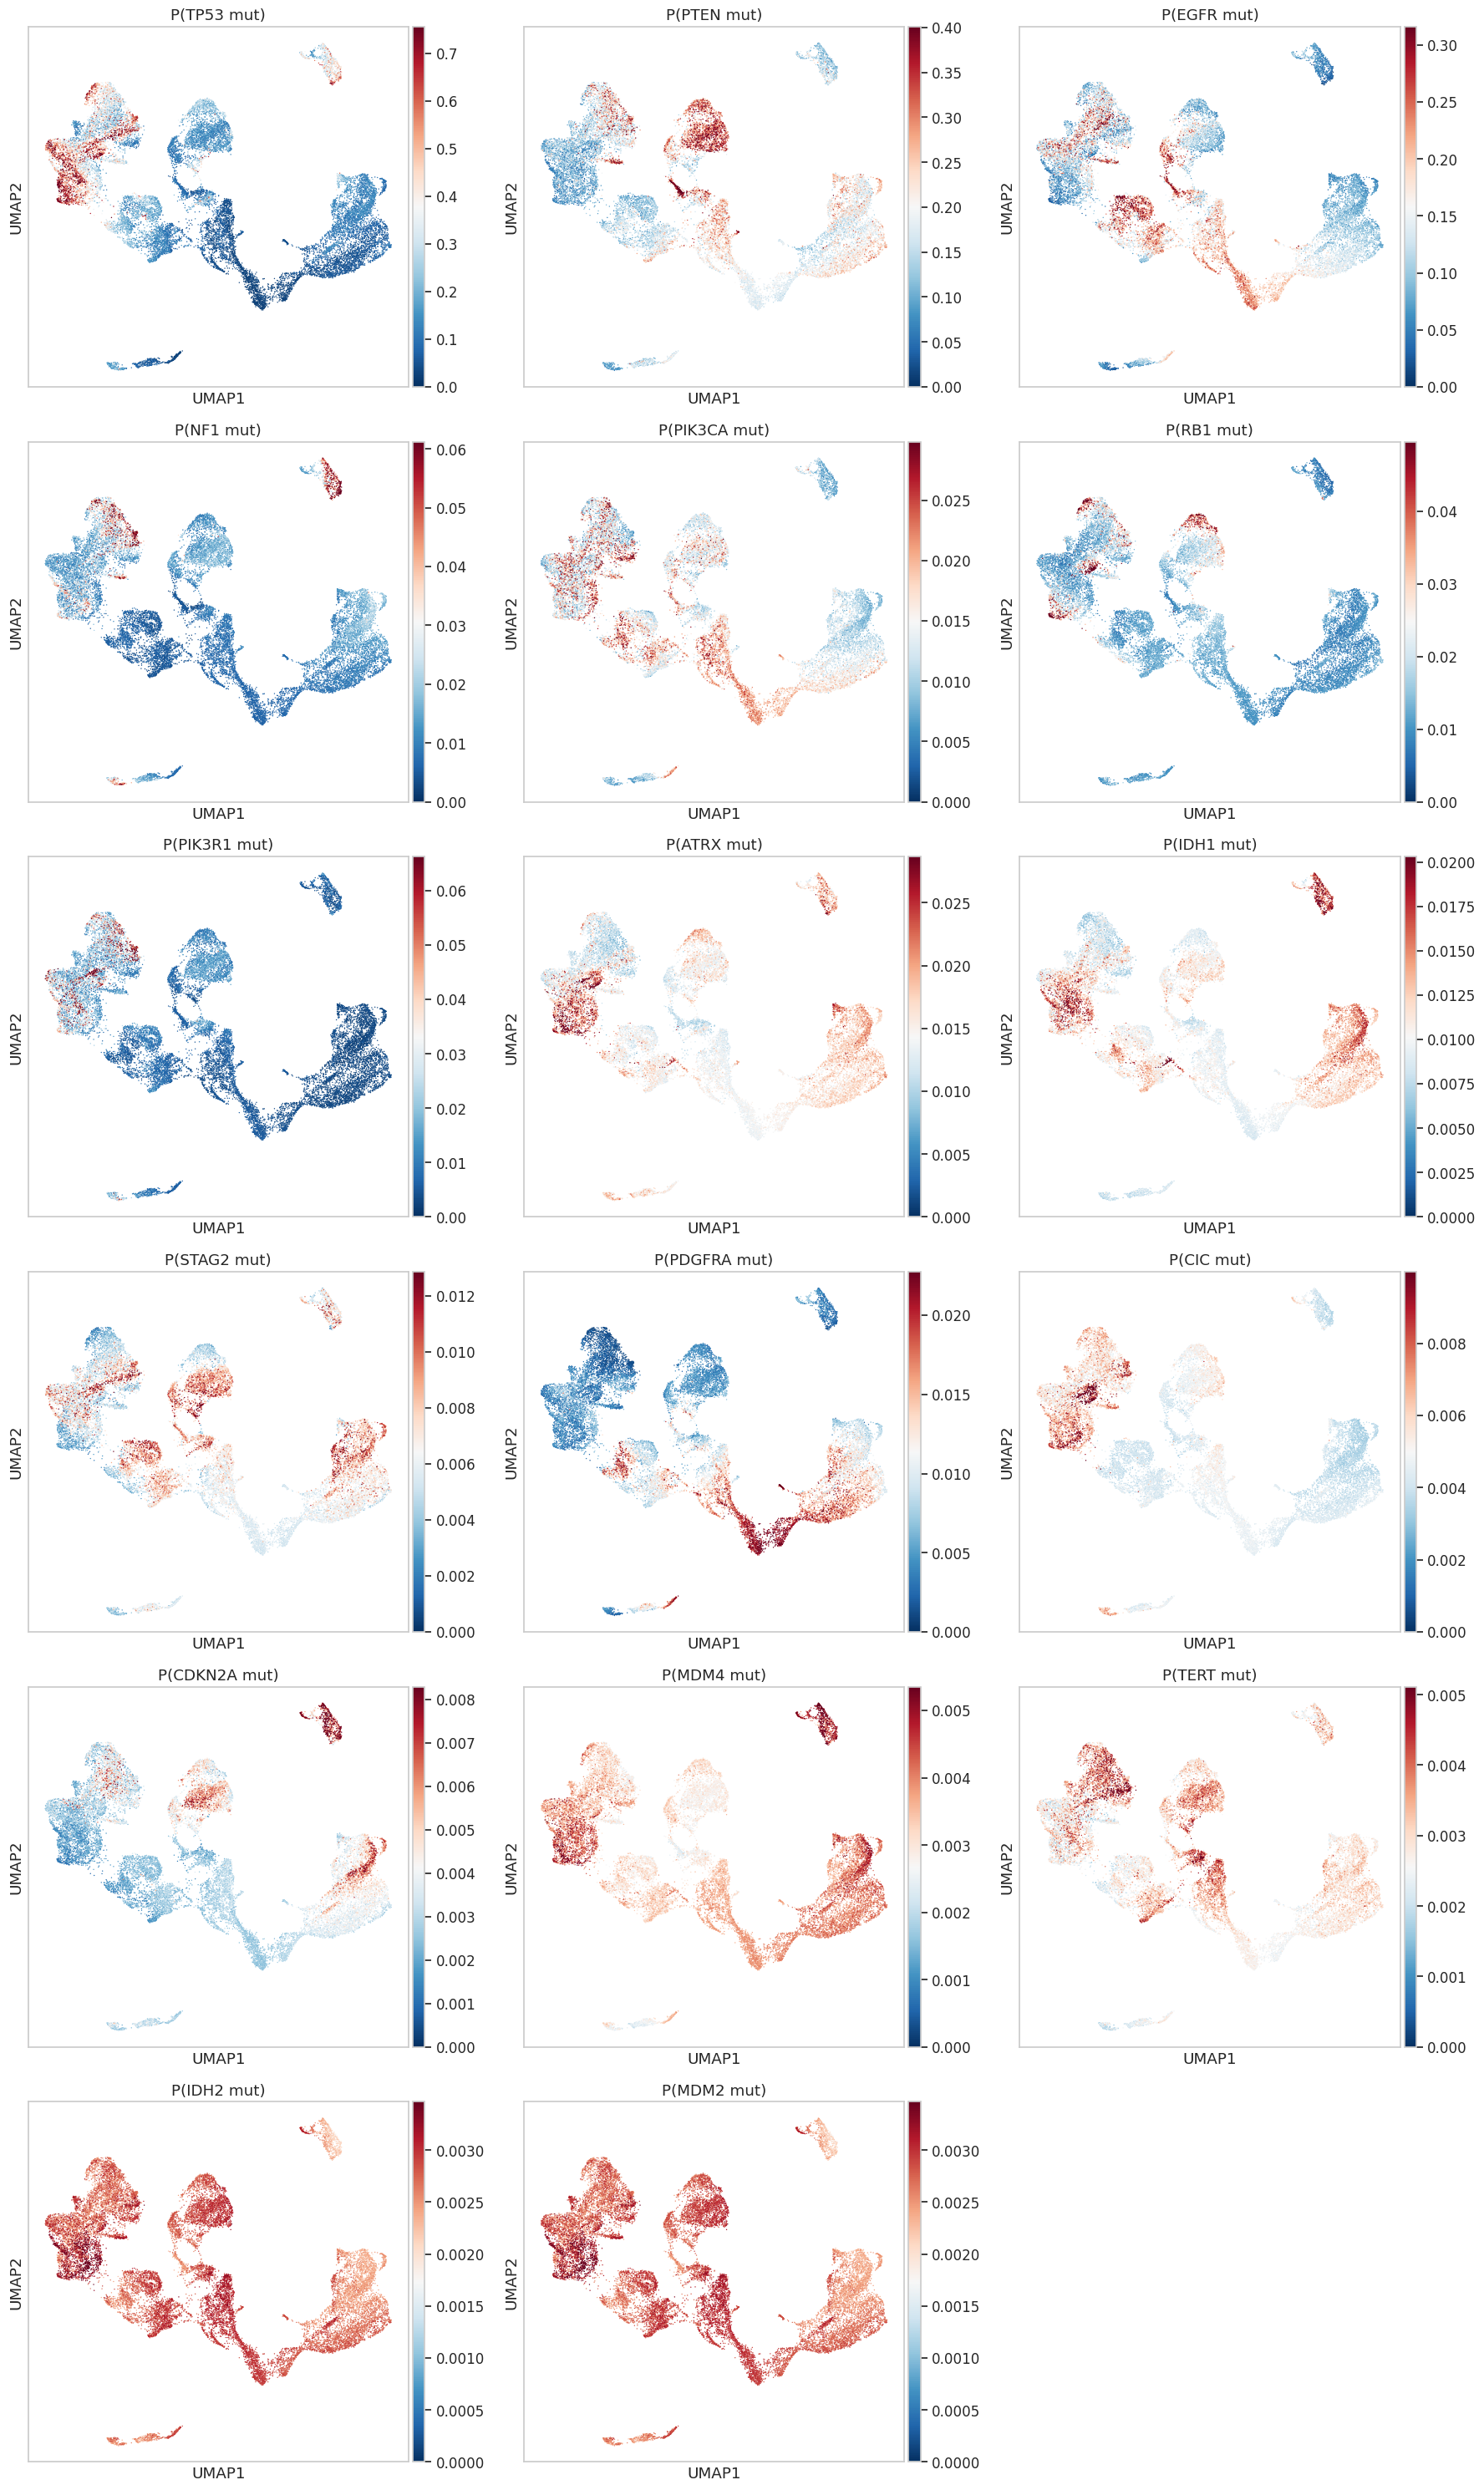

In [28]:
# -- UMAP on SVD latent embedding -----------------------------------------
adata_sc = compute_umap(adata_sc, obsm_key="X_svd")

top_muts = mutation_labels.sum().sort_values(ascending=False).index.tolist()
prob_cols = [f"mutation_prob_{g}" for g in top_muts
             if f"mutation_prob_{g}" in adata_sc.obs.columns]

# Cell type + top mutation UMAPs
ct_col = next((c for c in adata_sc.obs.columns
               if "type" in c.lower() or "celltype" in c.lower()
               or "cluster" in c.lower()), None)
if ct_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sc.pl.umap(adata_sc, color=ct_col, ax=axes[0], show=False, title="Cell type")
    sc.pl.umap(adata_sc, color=prob_cols[0] if prob_cols else ct_col,
               ax=axes[1], show=False, title=f"P({top_muts[0]} mut)")
    plt.tight_layout()
    fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_umap_overview.pdf"),
                bbox_inches="tight")
    plt.show()

# All mutation probability UMAPs
vmaxes = {c: max(float(np.percentile(adata_sc.obs[c].values, 99)), 0.0005)
          for c in prob_cols}
ncols = 3
nrows = int(np.ceil(len(prob_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()
for i, col in enumerate(prob_cols):
    gene = col.replace("mutation_prob_", "")
    sc.pl.umap(adata_sc, color=col, ax=axes[i], show=False,
               title=f"P({gene} mut)", vmin=0, vmax=vmaxes[col],
               cmap="RdBu_r", colorbar_loc="right", s=4)
for j in range(len(prob_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_mutation_probs_umap.pdf"),
            bbox_inches="tight")
plt.show()

# Heatmap: mean probability per cluster
if ct_col:
    fig, ax = plot_mutation_heatmap(adata_sc, cluster_key=ct_col, mutations=top_muts)
    fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_heatmap_{ct_col}.pdf"),
                bbox_inches="tight")
    plt.show()


In [30]:
print(adata_sc)


AnnData object with n_obs × n_vars = 22906 × 20530
    obs: 'sample', 'platform', 'n_genes', 'mutation_prob_IDH1', 'mutation_prob_IDH2', 'mutation_prob_TP53', 'mutation_prob_PTEN', 'mutation_prob_EGFR', 'mutation_prob_PIK3CA', 'mutation_prob_PIK3R1', 'mutation_prob_RB1', 'mutation_prob_CDKN2A', 'mutation_prob_NF1', 'mutation_prob_ATRX', 'mutation_prob_CIC', 'mutation_prob_TERT', 'mutation_prob_PDGFRA', 'mutation_prob_MDM2', 'mutation_prob_MDM4', 'mutation_prob_STAG2'
    uns: 'scope_mutations', 'scope_decomposition', 'scope_n_components'
    obsm: 'X_svd', 'X_umap'


In [29]:
adata_sc.write_h5ad(os.path.join(MODELS_DIR, f"{CANCER_TAG}_sc_with_mutation_probs.h5ad"))
print(f"Saved h5ad -> {MODELS_DIR}")


Saved h5ad -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/../models/GBM
